# MAF Full Sequences with ANODE

This notebook trains two MAF models using the ANODE approach:
1. **Background model** (`model_bg`): Trained on sideband (pure background)
2. **Data/Mixed model** (`model_data`): Trained on signal region (background + potential signal)

Anomaly score = `log_p_data - log_p_bg`

**Key changes from MAF_model_1.ipynb:**
- `input_dim = 2010` (was 134)
- `hidden_features = 512` (was 256)
- Uses FullSequenceDataset with padding

## Imports

In [7]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Subset, ConcatDataset
from nflows.flows.base import Flow
from nflows.distributions.normal import StandardNormal
from nflows.transforms.base import CompositeTransform
from nflows.transforms.autoregressive import MaskedAffineAutoregressiveTransform
from nflows.transforms.permutations import ReversePermutation
from torch.nn.utils import spectral_norm
import glob
import numpy as np
from sklearn.metrics import roc_auc_score
import matplotlib.pyplot as plt

from full_seq_dataset import FullSequenceDataset

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")

Using device: cuda


## Configuration

In [ ]:
# Model config
INPUT_DIM = 2010  # 30 steps * 67 features
HIDDEN_FEATURES = 256 
NUM_LAYERS = 6
CONTEXT_DIM = 1  # mjj conditioning

# Training config
BATCH_SIZE = 128
NUM_EPOCHS = 50
LEARNING_RATE = 1e-4
WEIGHT_DECAY = 1e-6

# Mass windows for ANODE (GeV)
# Signal region: 3310 - 3750 GeV (around 3500 GeV resonance)
# Sidebands: 2900-3310 and 3750-4100 GeV
SR_LOW = 3310
SR_HIGH = 3750
SB_LOW_START = 2900
SB_LOW_END = 3310
SB_HIGH_START = 3750
SB_HIGH_END = 4100

# split the data for faster training
USE_FRACTION = 0.7
SIG_TRAIN_FRACTION = 0.6

## Data Loading

In [ ]:
bg_train_files = sorted(glob.glob("../full_sequences_for_maf/bg_train_*.pt"))
bg_test_files = sorted(glob.glob("../full_sequences_for_maf/bg_test_*.pt"))
sig_files = sorted(glob.glob("../full_sequences_for_maf/sig_test_*.pt"))

n_sig_train = max(1, int(len(sig_files) * SIG_TRAIN_FRACTION))
sig_train_files = sig_files[:n_sig_train]
sig_test_files = sig_files[n_sig_train:]

n_train = max(1, int(len(bg_train_files) * USE_FRACTION))
n_bg_test = max(1, int(len(bg_test_files) * USE_FRACTION))

bg_train_files = bg_train_files[:n_train]
bg_test_files = bg_test_files[:n_bg_test]

print(f"Using {len(bg_train_files)} bg train files")
print(f"Using {len(sig_train_files)} sig train files (for signal region injection)")
print(f"Using {len(bg_test_files)} bg test files")
print(f"Using {len(sig_test_files)} sig test files")


Using 12 bg train files
Using 5 sig train files (for signal region injection)
Using 8 bg test files
Using 5 sig test files


In [4]:
# Load datasets
bg_train_dataset = FullSequenceDataset(bg_train_files)
sig_train_dataset = FullSequenceDataset(sig_train_files)

print(f"Background train samples: {len(bg_train_dataset)}")
print(f"Signal train samples: {len(sig_train_dataset)}")

Background train samples: 60000
Signal train samples: 25000


## Partition into Sideband and Signal Region

In [ ]:
# =============================================================================
# Partition into Sideband and Signal Region
# - Sideband: Pure background (for training model_bg)
# - Signal Region: Background + Injected Signal (for training model_data)
# =============================================================================

def get_region_indices(dataset):
    """Partition dataset into sideband and signal region based on mjj."""
    sr_indices = []  # Signal region
    sb_indices = []  # Sideband
    
    print("Partitioning data into Signal Region and Sidebands...")
    for i in range(len(dataset)):
        _, _, mjj_val = dataset[i]
        mjj_val = mjj_val.item() if isinstance(mjj_val, torch.Tensor) else mjj_val
        
        # Signal region: 3310-3750 GeV
        if SR_LOW <= mjj_val <= SR_HIGH:
            sr_indices.append(i)
        # Sidebands: 2900-3310 or 3750-4100 GeV  
        elif (SB_LOW_START <= mjj_val < SB_LOW_END) or (SB_HIGH_START < mjj_val <= SB_HIGH_END):
            sb_indices.append(i)
    
    print(f"Signal region samples: {len(sr_indices)}")
    print(f"Sideband samples: {len(sb_indices)}")
    return sr_indices, sb_indices

print("\n--- Background data ---")
bg_sr_indices, bg_sb_indices = get_region_indices(bg_train_dataset)

print("\n--- Signal data ---")
sig_sr_indices, _ = get_region_indices(sig_train_dataset)
print(f"\nSignal samples to inject into SR: {len(sig_sr_indices)}")



--- Background data ---
Partitioning data into Signal Region and Sidebands...
Signal region samples: 7764
Sideband samples: 16140

--- Signal data ---
Partitioning data into Signal Region and Sidebands...
Signal region samples: 19428
Sideband samples: 4519

Signal samples to inject into SR: 19428


In [ ]:
# Data Loaders

# Sideband loader: PURE BACKGROUND (for model_bg)
sb_loader = DataLoader(
    Subset(bg_train_dataset, bg_sb_indices),
    batch_size=BATCH_SIZE,
    shuffle=True
)

# Signal region loader: BACKGROUND + SIGNAL (for model_data)
sr_mixed_dataset = ConcatDataset([
    Subset(bg_train_dataset, bg_sr_indices),  # BG in signal region
    Subset(sig_train_dataset, sig_sr_indices)  # Injected signal
])

sr_loader = DataLoader(
    sr_mixed_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True
)

print(f"\nSideband batches (pure BG): {len(sb_loader)}")
print(f"Signal region batches (BG + Signal): {len(sr_loader)}")
print(f"Signal region composition: {len(bg_sr_indices)} BG + {len(sig_sr_indices)} Signal")



Sideband batches (pure BG): 127
Signal region batches (BG + Signal): 213
Signal region composition: 7764 BG + 19428 Signal


## Model Definition

In [ ]:
def apply_spectral_norm_to_maf(transform):
    """Apply spectral normalization to MAF layers for stability."""
    net = transform.autoregressive_net
    for name, module in net.named_modules():
        if 'MaskedLinear' in str(type(module)) or isinstance(module, nn.Linear):
            spectral_norm(module)
    return transform


class JetMAF(nn.Module):
    """Masked Autoregressive Flow for jet sequences."""
    
    def __init__(self, input_dim=INPUT_DIM, context_dim=CONTEXT_DIM,
                 hidden_features=HIDDEN_FEATURES, num_layers=NUM_LAYERS):
        super().__init__()
        
        self.input_dim = input_dim
        self.base_dist = StandardNormal(shape=[input_dim])
        
        transforms = []
        for _ in range(num_layers):
            layer = MaskedAffineAutoregressiveTransform(
                features=input_dim,
                hidden_features=hidden_features,
                context_features=context_dim,
                num_blocks=6,
                use_batch_norm=False
            )
            layer = apply_spectral_norm_to_maf(layer)
            transforms.append(layer)
            transforms.append(ReversePermutation(features=input_dim))
        
        self.flow = Flow(
            transform=CompositeTransform(transforms),
            distribution=self.base_dist
        )
    
    def log_prob(self, x, context=None):
        return self.flow.log_prob(x, context=context)
    
    def forward(self, x, context=None):
        return self.log_prob(x, context=context)

## Training Function

In [10]:
def train_maf(train_loader, model_name="maf", num_epochs=NUM_EPOCHS):
    """Train MAF model."""
    
    model = JetMAF().to(device)
    optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, 'min', patience=5, factor=0.5)
    
    print(f"\nTraining {model_name} on {len(train_loader)} batches...")
    
    for epoch in range(num_epochs):
        model.train()
        epoch_loss = 0
        num_batches = 0
        
        for x, labels, mjj in train_loader:
            x = x.to(device).float()
            context = (mjj.view(-1, 1).to(device).float()) / 1000.0
            
            optimizer.zero_grad()
            
            log_p = model.log_prob(x, context=context)
            loss = -torch.mean(log_p)
            
            if torch.isnan(loss):
                print("NaN detected! Skipping batch.")
                continue
            
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()
            
            epoch_loss += loss.item()
            num_batches += 1
        
        avg_loss = epoch_loss / num_batches if num_batches > 0 else float('inf')
        scheduler.step(avg_loss)
        
        # Per-dimension loss for comparison
        per_dim_loss = avg_loss / INPUT_DIM
        print(f"Epoch {epoch:02d} | NLL: {avg_loss:.1f} | Per-dim: {per_dim_loss:.3f} | LR: {optimizer.param_groups[0]['lr']:.2e}")
        
        # Save checkpoints
        if epoch >= 45:
            torch.save(model.state_dict(), f"{model_name}_ep{epoch}.pth")
    
    torch.save(model.state_dict(), f"{model_name}_final.pth")
    return model

## Train Background Model (Sideband)

In [11]:
print("="*70)
print("Training Background Model on Sideband")
print("="*70)

model_bg = train_maf(sb_loader, model_name="maf_bg_fullseq")

Training Background Model on Sideband

Training maf_bg_fullseq on 127 batches...
Epoch 00 | NLL: -680.0 | Per-dim: -0.338 | LR: 1.00e-04
Epoch 01 | NLL: -3174.0 | Per-dim: -1.579 | LR: 1.00e-04
Epoch 02 | NLL: -3708.3 | Per-dim: -1.845 | LR: 1.00e-04
Epoch 03 | NLL: -4000.3 | Per-dim: -1.990 | LR: 1.00e-04
Epoch 04 | NLL: -4265.1 | Per-dim: -2.122 | LR: 1.00e-04
Epoch 05 | NLL: -4410.4 | Per-dim: -2.194 | LR: 1.00e-04
Epoch 06 | NLL: -4604.2 | Per-dim: -2.291 | LR: 1.00e-04
Epoch 07 | NLL: -4736.3 | Per-dim: -2.356 | LR: 1.00e-04
Epoch 08 | NLL: -4907.7 | Per-dim: -2.442 | LR: 1.00e-04
Epoch 09 | NLL: -4891.0 | Per-dim: -2.433 | LR: 1.00e-04
Epoch 10 | NLL: -5051.5 | Per-dim: -2.513 | LR: 1.00e-04
Epoch 11 | NLL: -5127.6 | Per-dim: -2.551 | LR: 1.00e-04
Epoch 12 | NLL: -5250.7 | Per-dim: -2.612 | LR: 1.00e-04
Epoch 13 | NLL: -5320.2 | Per-dim: -2.647 | LR: 1.00e-04
Epoch 14 | NLL: -5252.5 | Per-dim: -2.613 | LR: 1.00e-04
Epoch 15 | NLL: -5375.9 | Per-dim: -2.675 | LR: 1.00e-04
Epoch 16

## Train Data Model (Signal Region)

In [12]:
print("="*70)
print("Training Data Model on Signal Region")
print("="*70)

model_data = train_maf(sr_loader, model_name="maf_data_fullseq")

Training Data Model on Signal Region

Training maf_data_fullseq on 213 batches...
Epoch 00 | NLL: -1535.8 | Per-dim: -0.764 | LR: 1.00e-04
Epoch 01 | NLL: -3503.5 | Per-dim: -1.743 | LR: 1.00e-04
Epoch 02 | NLL: -4062.9 | Per-dim: -2.021 | LR: 1.00e-04
Epoch 03 | NLL: -4375.6 | Per-dim: -2.177 | LR: 1.00e-04
Epoch 04 | NLL: -4596.3 | Per-dim: -2.287 | LR: 1.00e-04
Epoch 05 | NLL: -4809.2 | Per-dim: -2.393 | LR: 1.00e-04
Epoch 06 | NLL: -4878.3 | Per-dim: -2.427 | LR: 1.00e-04
Epoch 07 | NLL: -5011.9 | Per-dim: -2.493 | LR: 1.00e-04
Epoch 08 | NLL: -5210.3 | Per-dim: -2.592 | LR: 1.00e-04
Epoch 09 | NLL: -5204.5 | Per-dim: -2.589 | LR: 1.00e-04
Epoch 10 | NLL: -5331.3 | Per-dim: -2.652 | LR: 1.00e-04
Epoch 11 | NLL: -5420.2 | Per-dim: -2.697 | LR: 1.00e-04
Epoch 12 | NLL: -5512.5 | Per-dim: -2.743 | LR: 1.00e-04
Epoch 13 | NLL: -5561.4 | Per-dim: -2.767 | LR: 1.00e-04
Epoch 14 | NLL: -5653.0 | Per-dim: -2.812 | LR: 1.00e-04
Epoch 15 | NLL: -5719.4 | Per-dim: -2.845 | LR: 1.00e-04
Epoch 

## ANODE Evaluation

In [13]:
# Load test data
bg_test_dataset = FullSequenceDataset(bg_test_files)
sig_test_dataset = FullSequenceDataset(sig_test_files)

print(f"Background test samples: {len(bg_test_dataset)}")
print(f"Signal test samples: {len(sig_test_dataset)}")

Background test samples: 40000
Signal test samples: 24968


In [14]:
def compute_anode_scores(model_data, model_bg, dataset, batch_size=256):
    """Compute ANODE anomaly scores: log_p_data - log_p_bg"""
    
    model_data.eval()
    model_bg.eval()
    
    loader = DataLoader(dataset, batch_size=batch_size, shuffle=False)
    
    scores = []
    labels = []
    mjj_values = []
    
    with torch.no_grad():
        for x, label, mjj in loader:
            x = x.to(device).float()
            context = (mjj.view(-1, 1).to(device).float()) / 1000.0
            
            log_p_data = model_data.log_prob(x, context=context)
            log_p_bg = model_bg.log_prob(x, context=context)
            
            # ANODE score: log ratio
            log_ratio = log_p_data - log_p_bg
            
            scores.extend(log_ratio.cpu().numpy())
            labels.extend(label.numpy() if isinstance(label, torch.Tensor) else [label])
            mjj_values.extend(mjj.numpy() if isinstance(mjj, torch.Tensor) else [mjj])
    
    return np.array(scores), np.array(labels), np.array(mjj_values)

In [15]:
# Compute scores for test sets
print("Computing ANODE scores...")

bg_scores, bg_labels, bg_mjj = compute_anode_scores(model_data, model_bg, bg_test_dataset)
sig_scores, sig_labels, sig_mjj = compute_anode_scores(model_data, model_bg, sig_test_dataset)

print(f"Background scores: {len(bg_scores)}")
print(f"Signal scores: {len(sig_scores)}")

Computing ANODE scores...
Background scores: 40000
Signal scores: 24968


In [17]:
# Combine for AUC calculation
y_true = np.concatenate([np.zeros(len(bg_scores)), np.ones(len(sig_scores))])
y_scores = np.concatenate([bg_scores, sig_scores])

# Clean up any NaN/Inf
y_scores = np.nan_to_num(y_scores, nan=0.0, posinf=100.0, neginf=-100.0)

# Compute AUC
auc = roc_auc_score(y_true, y_scores)

print(f"\n{'='*70}")
print(f"ANODE ROC AUC: {auc:.4f}")
print(f"{'='*70}")


ANODE ROC AUC: 0.7937


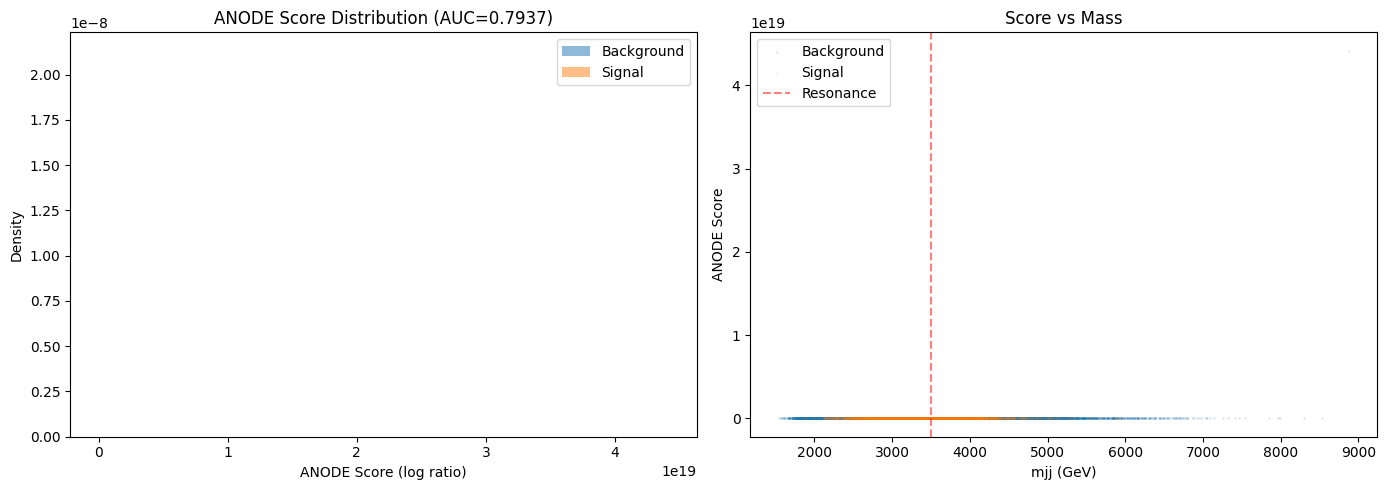

In [18]:
# Plot score distributions
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Score distribution
axes[0].hist(bg_scores, bins=50, alpha=0.5, label='Background', density=True)
axes[0].hist(sig_scores, bins=50, alpha=0.5, label='Signal', density=True)
axes[0].set_xlabel('ANODE Score (log ratio)')
axes[0].set_ylabel('Density')
axes[0].set_title(f'ANODE Score Distribution (AUC={auc:.4f})')
axes[0].legend()

# Score vs mjj
axes[1].scatter(bg_mjj, bg_scores, alpha=0.1, s=1, label='Background')
axes[1].scatter(sig_mjj, sig_scores, alpha=0.1, s=1, label='Signal')
axes[1].set_xlabel('mjj (GeV)')
axes[1].set_ylabel('ANODE Score')
axes[1].set_title('Score vs Mass')
axes[1].axvline(3500, color='red', linestyle='--', alpha=0.5, label='Resonance')
axes[1].legend()

plt.tight_layout()
plt.savefig('anode_fullseq_results.png', dpi=150)
plt.show()

## SIC Curve

Maximum SIC: 1.64
At TPR: 0.878, FPR: 0.286125


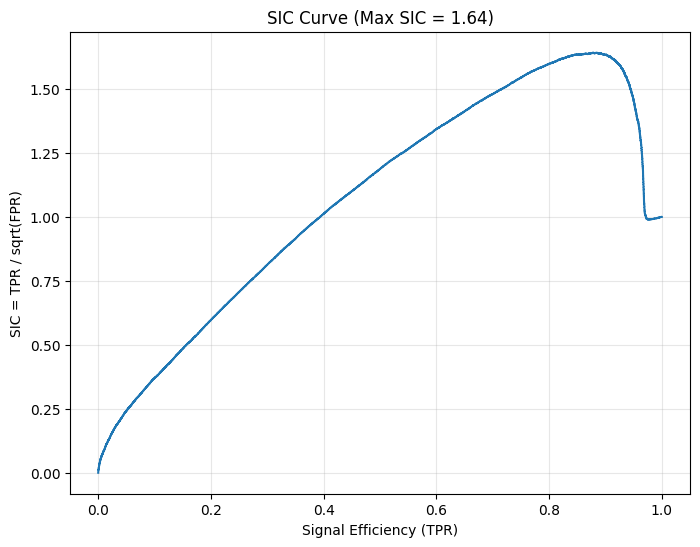

In [19]:
from sklearn.metrics import roc_curve

fpr, tpr, thresholds = roc_curve(y_true, y_scores)

# SIC = TPR / sqrt(FPR)
with np.errstate(divide='ignore', invalid='ignore'):
    sic = tpr / np.sqrt(fpr)
    sic = np.nan_to_num(sic, nan=0.0, posinf=0.0)

max_sic = np.max(sic)
max_sic_idx = np.argmax(sic)

print(f"Maximum SIC: {max_sic:.2f}")
print(f"At TPR: {tpr[max_sic_idx]:.3f}, FPR: {fpr[max_sic_idx]:.6f}")

plt.figure(figsize=(8, 6))
plt.plot(tpr, sic)
plt.xlabel('Signal Efficiency (TPR)')
plt.ylabel('SIC = TPR / sqrt(FPR)')
plt.title(f'SIC Curve (Max SIC = {max_sic:.2f})')
plt.grid(True, alpha=0.3)
plt.savefig('sic_fullseq.png', dpi=150)
plt.show()